# Validação 08 — Recuperação semântica multilíngue

## Goal

Comprovar que embeddings multilíngues recuperam trechos científicos em inglês a partir de uma alegação em português e comparar o resultado com a linha de base BM25.

## Setup

O notebook usa o mesmo artigo e os mesmos trechos da validação anterior. A única variável comparada é o método de recuperação. Na primeira execução, o `sentence-transformers` baixa o modelo aberto configurado.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
from pprint import pprint
import os
import sys

import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from fatofake import (
    DEFAULT_EMBEDDING_MODEL,
    Bm25Index,
    ChunkingConfig,
    PmcClient,
    PubMedClient,
    SemanticIndex,
    SentenceTransformerEncoder,
    chunk_article_content,
    prepare_search_plan,
    retrieve_article_content,
    search_pubmed,
    validate_analysis_input,
)

executed_at = datetime.now(timezone.utc).isoformat()
print(f"Execução UTC: {executed_at}")

Execução UTC: 2026-09-23T14:18:18.873051+00:00


## Steps

### 1. Recuperar e recortar a fonte

Reexecutamos as etapas anteriores para que o notebook não dependa de estado oculto.

In [2]:
class PmidQueryPlanner:
    def generate_queries(self, claim: str) -> list[str]:
        return ["33431520[pmid]"]

claim = "Beber café pode alterar o risco de câncer de próstata."
analysis_input = validate_analysis_input(claim)
search_plan = prepare_search_plan(analysis_input, PmidQueryPlanner())
pubmed_result = search_pubmed(
    search_plan,
    PubMedClient(email=os.getenv("NCBI_EMAIL"), api_key=os.getenv("NCBI_API_KEY")),
    max_results_per_query=1,
)
content = retrieve_article_content(
    pubmed_result.publications[0],
    PmcClient(email=os.getenv("NCBI_EMAIL"), api_key=os.getenv("NCBI_API_KEY")),
)
chunks = chunk_article_content(content, ChunkingConfig(max_words=120, overlap_words=20))
print(f"Fonte: {content.pmcid} | trechos: {len(chunks)} | alegação: {claim}")

Fonte: PMC7805365 | trechos: 35 | alegação: Beber café pode alterar o risco de câncer de próstata.


### 2. Executar os dois rankings

O BM25 depende de termos compartilhados; o modelo semântico compara vetores multilíngues. As escalas dos scores são diferentes e não devem ser comparadas diretamente.

In [3]:
top_k = 5
lexical_results = Bm25Index(chunks).search(claim, top_k=top_k)
model_name = os.getenv("EMBEDDING_MODEL", DEFAULT_EMBEDDING_MODEL)
semantic_index = SemanticIndex(chunks, SentenceTransformerEncoder(model_name))
semantic_results = semantic_index.search(claim, top_k=top_k)

print(f"Modelo semântico: {semantic_index.model_name}")
print(f"Resultados BM25: {len(lexical_results)} | semânticos: {len(semantic_results)}")

/private/tmp/fatofake-notebook-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 24943.71it/s]

Modelo semântico: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Resultados BM25: 5 | semânticos: 5


In [4]:
def ranking_rows(results):
    return [
        {
            "rank": result.rank,
            "score": round(result.score, 4),
            "section": result.chunk.section,
            "chunk_id": result.chunk.chunk_id,
            "preview": result.chunk.text[:220],
            "source_url": result.chunk.source_url,
        }
        for result in results
    ]

print("Ranking semântico:")
pprint(ranking_rows(semantic_results))
print("\nRanking BM25:")
pprint(ranking_rows(lexical_results))

Ranking semântico:
[{'chunk_id': '33431520:5:1:e6073a4e4d5c6e1b',
  'preview': 'This study suggests that increased coffee consumption may be '
             'associated with a reduced risk of prostate cancer. Further '
             'research is still warranted to explore the underlying mechanisms '
             'and active compounds in coffee. If ',
  'rank': 1,
  'score': 0.8991,
  'section': 'Conclusions',
  'source_url': 'https://pmc.ncbi.nlm.nih.gov/articles/PMC7805365/'},
 {'chunk_id': '33431520:1:4:b46f6ee9c488ee7c',
  'preview': 'different subgroups.22 23 Since then, five cohort studies have '
             'explored the association but still reported inconsistent '
             'results.24–28 It was hypothesised that higher coffee consumption '
             'was associated with an increased ri',
  'rank': 2,
  'score': 0.8741,
  'section': 'Introduction',
  'source_url': 'https://pmc.ncbi.nlm.nih.gov/articles/PMC7805365/'},
 {'chunk_id': '33431520:4:1:7125e244fa2c7203',
  'previe

### 3. Comparar a seleção

A figura mostra quantos dos dez lugares possíveis são compartilhados ou exclusivos de cada método. Ela compara composição; não compara os scores incompatíveis.

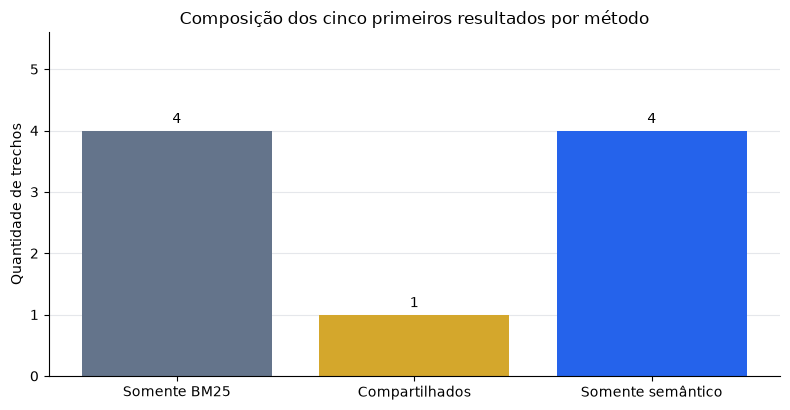

{'Somente BM25': 4, 'Compartilhados': 1, 'Somente semântico': 4}


In [5]:
lexical_ids = {result.chunk.chunk_id for result in lexical_results}
semantic_ids = {result.chunk.chunk_id for result in semantic_results}
comparison = {
    "Somente BM25": len(lexical_ids - semantic_ids),
    "Compartilhados": len(lexical_ids & semantic_ids),
    "Somente semântico": len(semantic_ids - lexical_ids),
}

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(
    comparison.keys(),
    comparison.values(),
    color=["#64748b", "#d4a72c", "#2563eb"],
)
ax.bar_label(bars, padding=3)
ax.set_title("Composição dos cinco primeiros resultados por método")
ax.set_ylabel("Quantidade de trechos")
ax.set_ylim(0, top_k + 0.6)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e7eb", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
display(
    fig,
    metadata={
        "image/png": {
            "alt": (
                "Gráfico de barras com quatro resultados exclusivos do BM25, "
                "um compartilhado e quatro exclusivos da busca semântica."
            )
        }
    },
)
plt.close(fig)

print(comparison)

## Checks

As verificações cobrem ordenação, unicidade, proveniência, resultado bilíngue e repetibilidade do ranking semântico.

In [6]:
assert len(semantic_results) == top_k
assert [result.rank for result in semantic_results] == list(range(1, top_k + 1))
assert all(
    previous.score >= current.score
    for previous, current in zip(semantic_results, semantic_results[1:])
)
assert len(semantic_ids) == top_k
assert all(result.chunk.pmid == "33431520" for result in semantic_results)
assert all(result.chunk.pmcid == "PMC7805365" for result in semantic_results)
assert all(result.chunk.source_url == content.pmc_url for result in semantic_results)
assert any(
    "prostate cancer" in result.chunk.text.casefold()
    for result in semantic_results
)
assert sum(comparison.values()) == len(lexical_ids | semantic_ids)

second_run = semantic_index.search(claim, top_k=top_k)
assert [result.chunk.chunk_id for result in semantic_results] == [
    result.chunk.chunk_id for result in second_run
]

print(
    f"Validação aprovada: {top_k} resultados semânticos, "
    f"com {len(lexical_ids & semantic_ids)} também presentes no BM25."
)

Validação aprovada: 5 resultados semânticos, com 1 também presentes no BM25.


## Next Steps

A recuperação semântica estará validada quando todas as células forem executadas sem erros. A próxima etapa será fundir BM25 e embeddings em um ranking híbrido, sem comparar diretamente as escalas dos scores.